In [1]:
import pandas as pd

#importing z score dataframes

df_SL = pd.read_csv('z_score_df_SL_over_US_071626.csv').set_index('peptide')

df_hbdb = pd.read_csv('z_hbdb_loo_results_071626.csv').set_index('peptide')

#importing RPK dataframes

df_SL_rpk = pd.read_csv('./preprocessing/earliest_tp_rpk_avg_value_for_cohort_techreps_071626.csv').set_index('peptide')

df_hbdb_rpk = pd.read_csv('./preprocessing/hbdb_pass_100k_techreps_averaged_071626.csv').set_index('peptide')

peps_metadata = pd.read_csv('lassa_library_sequences_species_standardized_070726.csv').set_index('seq_id')

In [2]:
peps_keep = pd.read_csv('peps_passing_z_score_5_in_10_or_more_SL_971826.csv').set_index('peptide')

In [3]:
#log transform the rpk matrices same way as for the z score analysis 
import pandas as pd
import numpy as np

df_SL_rpk = df_SL_rpk.apply(pd.to_numeric, errors="coerce").fillna(0.0) #converts every column to a numeric type, if cannot be converted, fills with Nan, but then later NaN gets converted to 0.0

df_SL_log_rpk = np.log10(df_SL_rpk + 1.0)

df_hbdb_rpk = df_hbdb_rpk.apply(pd.to_numeric, errors='coerce').fillna(0.0) #converts every column to a numeric type, if cannot be converted, fills with Nan, but then later NaN gets converted to 0.0

df_hbdb_log_rpk = np.log10(df_hbdb_rpk + 1.0)

In [4]:
#subset to only significant peptides 

peps_metadata = peps_metadata.loc[peps_keep.index]

In [5]:
import numpy as np

df_plot_z_sores = pd.concat([df_SL, df_hbdb], axis=1)

df_plot_rpk = pd.concat([df_SL_rpk, df_hbdb_rpk], axis=1)

df_plot_log_rpk = pd.concat([df_SL_log_rpk, df_hbdb_log_rpk], axis=1)

#subset to peps of interest

df_plot_z_sores_sig_peps = df_plot_z_sores.loc[peps_keep.index]

df_plot_rpk_sig_peps = df_plot_rpk.loc[peps_keep.index]

df_plot_log_rpk_sig_peps = df_plot_log_rpk.loc[peps_keep.index]


In [6]:
df_plot_z_sores_sig_peps_long = pd.melt(df_plot_z_sores_sig_peps.reset_index(), id_vars='peptide', var_name='sample_id', value_name='z_score')

In [7]:
peps_metadata = peps_metadata.reset_index()

df_plot_z_sores_sig_peps_long_w_metadata = pd.merge(df_plot_z_sores_sig_peps_long, peps_metadata[['peptide', 'sequence', 'accession', 'protein_name', 'order', 'family', 'genus', 'species', 'isolate', 'collection_date_standardized', 'geo_loc_name']], on='peptide', how='left')

In [8]:
df_plot_z_sores_sig_peps_long_w_metadata['category'] = 'US'

mask = df_plot_z_sores_sig_peps_long_w_metadata['sample_id'].str.startswith(('C-', 'S-'))

df_plot_z_sores_sig_peps_long_w_metadata.loc[mask, 'category'] = 'SL'

In [9]:
df_plot_z_sores_sig_peps_long_w_metadata.genus.unique()

array(['Mammarenavirus', 'Hartmanivirus', 'Antennavirus',
       'Reptarenavirus', 'Innmovirus', 'Arenavirus', 'Morbillivirus',
       'Orthorubulavirus', 'Rubivirus', 'Orthoflavivirus', 'Alphavirus',
       'unclassified Filoviridae', 'Dianlovirus', 'Orthomarburgvirus',
       'Cuevavirus', 'Tapjovirus', 'Orthoebolavirus', 'Thamnovirus',
       'Striavirus', 'Orthonairovirus', 'Norwavirus',
       'unclassified Nairoviridae', 'Unclassified Nairoviridae',
       'Ocetevirus', 'Xinspivirus', 'Sabavirus', 'Sitinavirus',
       'Shaspivirus', 'Striwavirus', 'Orthohantavirus', 'Actinovirus',
       'unclassified Hantaviridae', 'Percilovirus', 'Loanvirus',
       'Agnathovirus', 'Reptillovirus', 'Bandavirus', 'Phlebovirus',
       'Olpivirus', 'Uukuvirus', 'Pidchovirus', 'Tanzavirus', 'Homo',
       'Trypanosoma', 'Plasmodium', 'Henipavirus', 'Parahenipavirus'],
      dtype=object)

In [10]:
import seaborn as sns

genera = peps_metadata['genus'].fillna('unknown').unique()
palette = sns.color_palette('tab20', n_colors=len(genera))
genus_pal = dict(zip(genera, palette))

In [11]:
df_SL = df_SL.loc[peps_keep.index]

sig_peps_pass_z_5 = (df_SL > 5).sum(axis=1).sort_values(ascending=False)

In [12]:
sig_peps_pass_z_5 = pd.DataFrame(sig_peps_pass_z_5)

In [13]:
sig_peps_pass_z_5['frac_enriched'] = sig_peps_pass_z_5[0].div(df_SL.shape[1])

In [14]:
peps_metadata = peps_metadata.reset_index()
sig_peps_pass_z_5 = sig_peps_pass_z_5.reset_index()

In [15]:
sig_peps_pass_z_5 = pd.merge(sig_peps_pass_z_5, peps_metadata[['peptide', 'genus']], on='peptide', how='left')
top_hits = sig_peps_pass_z_5

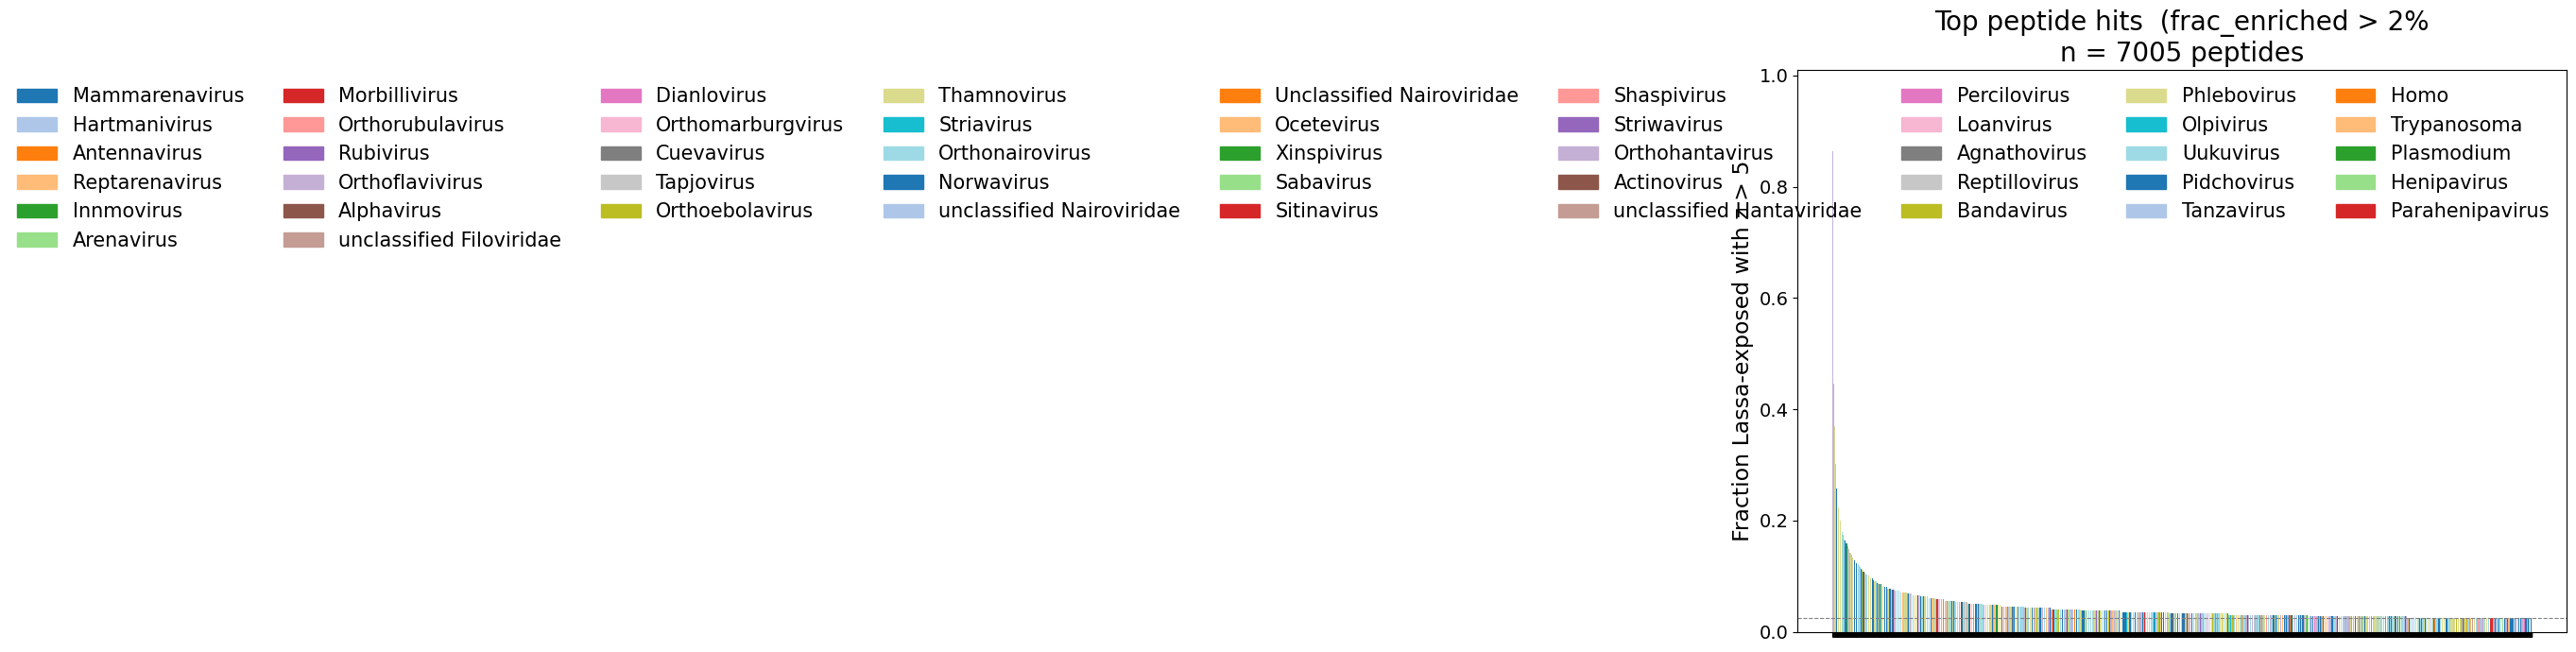

In [16]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

FRAC_MIN = 0.025
Z_THRESH = 5

fig1, ax1 = plt.subplots(figsize=(20, 7))

bar_colors = [genus_pal[g] for g in top_hits['genus'].fillna('unknown')]

ax1.bar(range(len(top_hits)), top_hits['frac_enriched'], color=bar_colors, edgecolor='none')

ax1.axhline(FRAC_MIN, color='grey', lw=0.8, ls='--', label=f'threshold {int(FRAC_MIN*100)}%')
ax1.set_xticks(range(len(top_hits)))
"""ax1.set_xticklabels(
    [f"{r['species_corr']}"
        for _, r in top_hits.iterrows()],
    rotation=90, fontsize=15)"""
ax1.set_xticklabels([])
ax1.set_ylabel(f'Fraction Lassa-exposed with z > {Z_THRESH}', fontsize=17)
ax1.tick_params(axis='y', labelsize=14)
ax1.set_title(
    f'Top peptide hits  (frac_enriched > {int(FRAC_MIN*100)}%\n'
    f'n = {len(top_hits)} peptides',
    fontsize=20)
legend_patches = [mpatches.Patch(color=c, label=g) for g, c in genus_pal.items()]
ax1.legend(handles=legend_patches, fontsize=15, frameon=False,
            loc='upper right', ncol=max(1, len(genera)//5))
plt.tight_layout()
plt.show()

In [17]:
top_hits_genus_peptide_sum = top_hits.groupby('genus').size()

In [18]:
mask = top_hits_genus_peptide_sum > 100

In [19]:
top_hits_genus_peptide_sum_filtered = top_hits_genus_peptide_sum[mask]
top_hits_genus_peptide_sum = top_hits_genus_peptide_sum_filtered

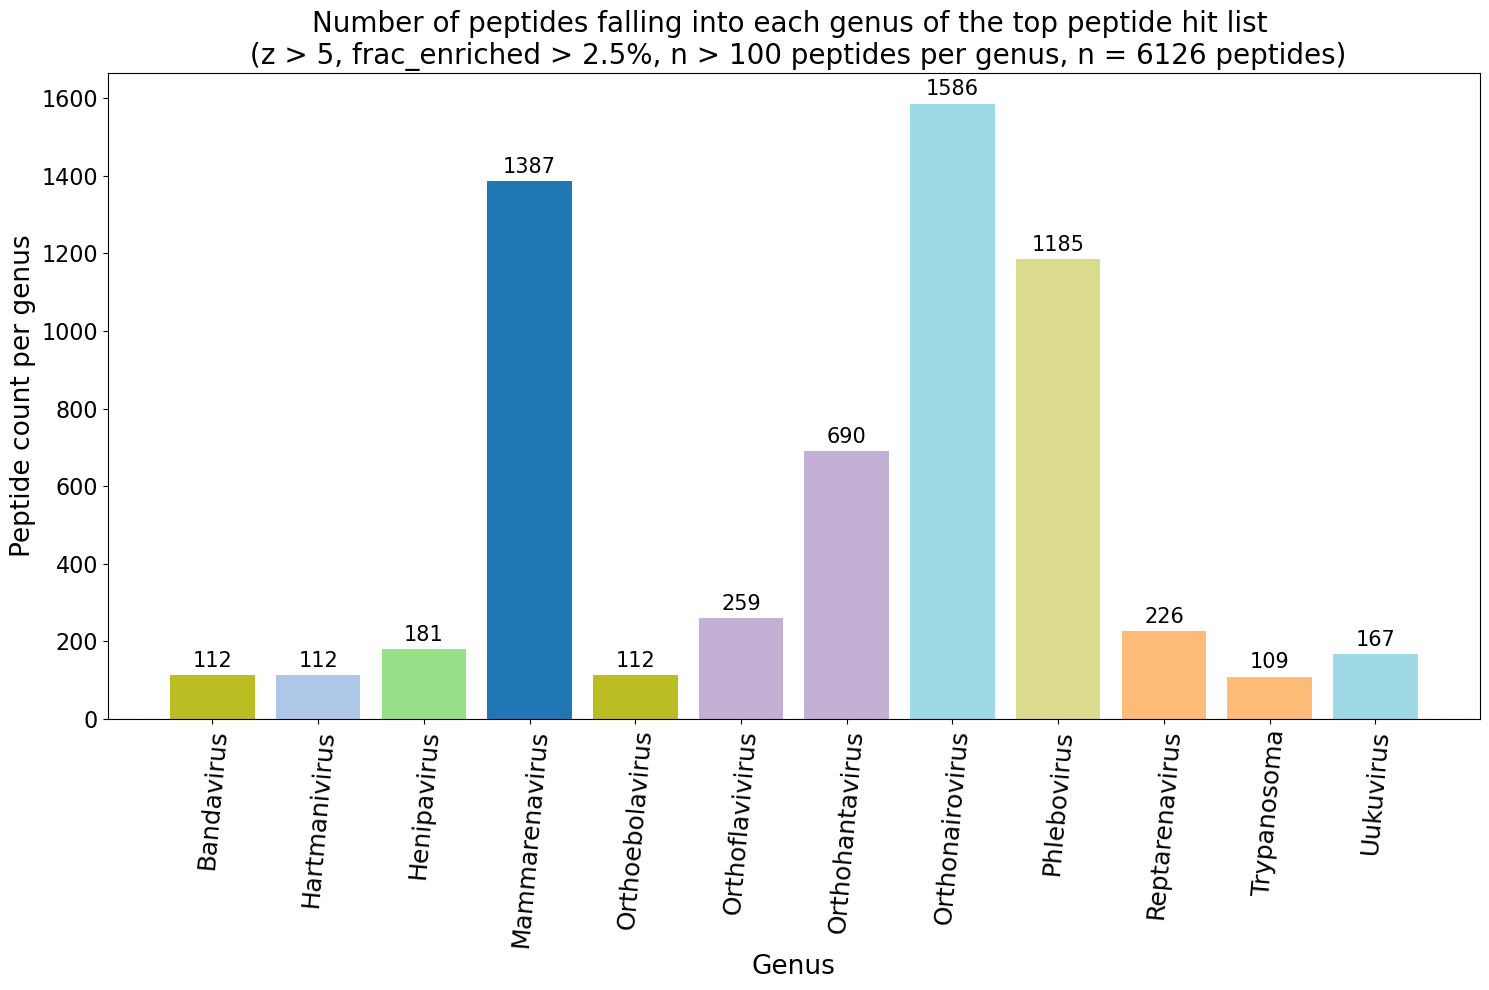

In [27]:
fig1, ax1 = plt.subplots(figsize=(15, 10))

bar_colors = [genus_pal[g] for g in top_hits_genus_peptide_sum.index]

ax1.bar(range(len(top_hits_genus_peptide_sum)), top_hits_genus_peptide_sum.values, color=bar_colors, edgecolor='none')
ax1.axhline(FRAC_MIN, color='grey', lw=0.8, ls='--', label=f'threshold {float(FRAC_MIN*100)}%')
ax1.set_xticks(range(len(top_hits_genus_peptide_sum)))
ax1.set_xticklabels(top_hits_genus_peptide_sum.index,
    rotation=85, fontsize=18)
ax1.set_xlabel('Genus', fontsize=19)
ax1.set_ylabel('Peptide count per genus', fontsize=19)
ax1.tick_params(axis='y', labelsize=16)

ax1.set_title(
    f'Number of peptides falling into each genus of the top peptide hit list \n (z > {Z_THRESH}, frac_enriched > {float(FRAC_MIN*100)}%, n > 100 peptides per genus, n = {top_hits_genus_peptide_sum.sum()} peptides)',
    fontsize=20)

for container in ax1.containers:
    ax1.bar_label(container, padding=3, fontsize=15)


plt.tight_layout()
plt.show()

In [21]:
plot_df = df_plot_z_sores.reset_index().fillna(0)

plot_df = pd.merge(plot_df, peps_metadata[['genus', 'peptide']], on='peptide', how='left')

plot_df = plot_df.set_index('peptide')

mask = top_hits_genus_peptide_sum > 100

In [22]:
plot_df_top_genuses = plot_df[plot_df["genus"].isin(mask.index)]

In [23]:
plot_df = plot_df_top_genuses

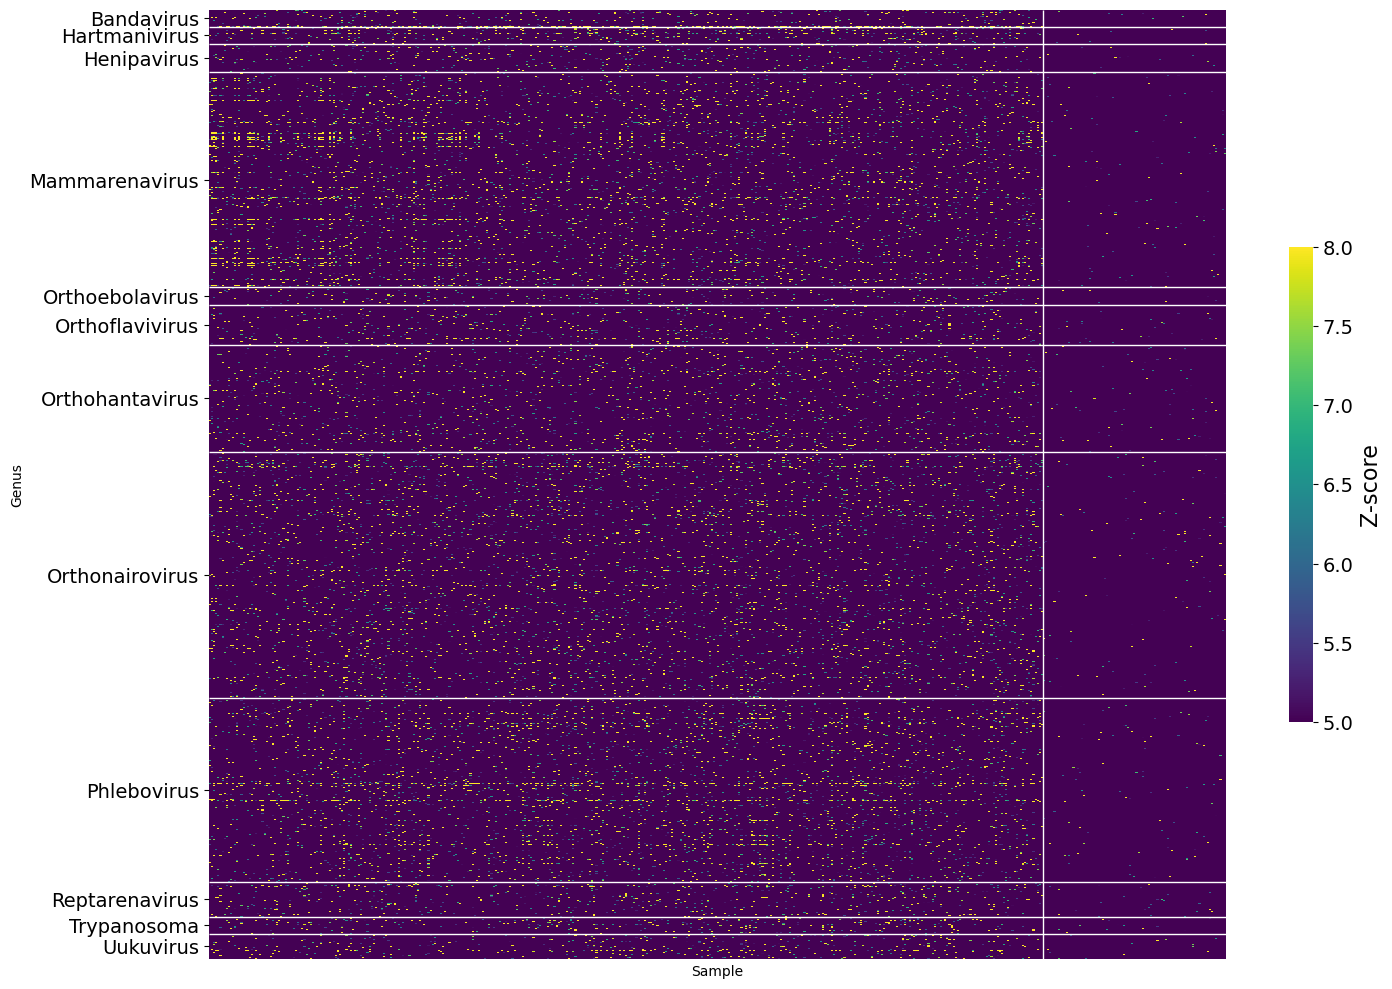

In [ ]:
#sort by genus

plot_df = plot_df.sort_values(["genus", plot_df.index.name if plot_df.index.name else plot_df.index.to_series()])

#sort columns - S- and C- first, then HBDB

sample_cols = [c for c in plot_df.columns if c!= 'genus']

hbdb_cols = sorted([c for c in sample_cols if str(c).startswith("HBDB-")])
S_cols = sorted([c for c in sample_cols if str(c).startswith("S-")])
C_cols = sorted([c for c in sample_cols if str(c).startswith("C-")])

ordered_cols = S_cols + C_cols + hbdb_cols

#separate matrix for heatmap
heatmap_data = plot_df.drop(columns=['genus'])[ordered_cols]

genus_pep_counts = plot_df['genus'].value_counts(sort=False)
genus_order = plot_df['genus'].drop_duplicates().tolist()

boundaries = genus_pep_counts.cumsum().to_numpy()[:-1] #cumsum is cumulative sum. 
centers = []
start=0

for g in genus_order:
    n = genus_pep_counts[g]
    centers.append(start+n / 2 - 0.5)
    start += n


hbdb_boundary = len(S_cols + C_cols)

fig, ax = plt.subplots(figsize=(15, 10))

sns.heatmap(
    heatmap_data,
    cmap="viridis",
    yticklabels=False,   # hide peptide names
    xticklabels=False,
    ax=ax,
    cbar_kws={"label": "z score", "shrink": 0.5},
    vmin=5, vmax=8
)

# Get the colorbar
cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=14)
# Make the label larger
cbar.set_label("Z-score", fontsize=16)

# Add horizontal lines between genus groups
for b in boundaries:
    ax.hlines(b, *ax.get_xlim(), colors="white", linewidth=1.0)


# Put genus names at the center of each group
ax.set_yticks(centers)
ax.set_yticklabels(genus_order, rotation=0, fontsize=14)

ax.vlines(hbdb_boundary, *ax.get_ylim(), colors="white", linewidth=1.0)


ax.set_xlabel("Sample")
ax.set_ylabel("Genus")
plt.tight_layout()
plt.show()

### for each of the genuses with > 100 peptides, have a boxplot with num. seroreactive peptides per person, SL vs US 

In [ ]:
plot_df  = plot_df.drop(columns='genus')

In [31]:
#convert to binary matrix

plot_df_binary =  plot_df > 5

In [33]:
plot_df_binary = pd.merge(plot_df_binary, peps_metadata[['peptide', 'genus']], on='peptide', how='left')

In [ ]:
plot_df_binary = plot_df_binary.set_index("peptide")

In [ ]:
genus_counts = plot_df_binary.groupby('genus').sum()

In [57]:
plot_df = (
    genus_counts
    .T #samples become rows
    .reset_index(names="sample")
    .melt(id_vars='sample', var_name='genus', value_name='n_seroreactive')
)

plot_df['category'] = plot_df['sample'].str.startswith("HBDB-").map({True: "US Healthy", False:"Sierra Leone"})

/tmp/ipykernel_3604874/1715713813.py:12: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(


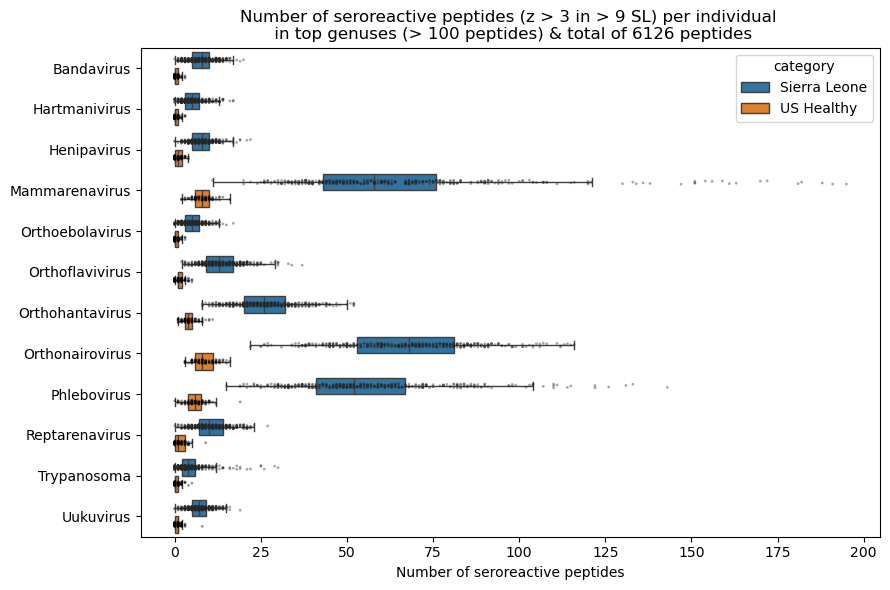

In [77]:
plt.figure(figsize=(9, 6))

sns.boxplot(
    data=plot_df,
    x="n_seroreactive",
    y="genus",
    hue="category",
    orient="h",
    showfliers=False,
)

sns.stripplot(
    data=plot_df,
    x="n_seroreactive",
    y="genus",
    hue="category",
    orient="h",
    dodge=True,
    alpha=0.4,
    size=2,
    color="black",
    legend=False,
)

plt.xlabel("Number of seroreactive peptides")
plt.ylabel("")
plt.title(f"Number of seroreactive peptides (z > 3 in > 9 SL) per individual \n in top genuses (> 100 peptides) & total of {plot_df_top_genuses.shape[0]} peptides")
plt.tight_layout()